In [1]:
###
# The following adds the modules required for the code to run.
###
import numpy as np
import time
import matplotlib.pyplot as plt
import dlanalysis as dla

In [2]:
class Walk2D:
    def __init__(self, n, seed):
        # This starts a timer. Used to calculate how long the code tool to run.
        self.start_time = time.time()
        # N is the number of particles the lattice will be made up of.
        self.N = n
        # seed is used to set the initial conditions in any random functions.
        self.seed = seed
        self.r = 1
        self.randx = np.zeros(self.N)
        self.randy = np.zeros(self.N)
        self.temp_thetas = np.random.uniform(-np.pi, np.pi, size=self.N)
        print('\n---------------------------\n')
        print('Number of points=', self.N)
        print('\nSeed selected=', self.seed)
        # generates a random seed, used to produce the same plot multiple times.
        np.random.seed(self.seed)
        self.initial_walk()
        self.my_plot()
        self.write_file()
        self.analyse()

    ###
    # initial_walk generates an array of points representing the locations of the
    # particles in the lattice.
    # It also calls the function used to increase the radius of the circle of
    # the particles
    # It then calls the function used to plot the lattice.
    ###
    def walk(self, i=1):
        """
        generate a particle on a circle
        is particle touching another particle function
        Yes:
            If a particle touches a circle? increase circle size
            walk for next particle i+1
        No:
            move particle
            walk for current particle i
        """
        # Sets a particle on the circle's circumference.
        # self.randx[i] = self.r * np.cos(self.temp_thetas[i])
        # self.randy[i] = self.r * np.sin(self.temp_thetas[i])
        # while True:
        #     if self.randx[i] ** 2 + self.randy[i] ** 2 == self.r ** 2:
        #         self.new_dist()
        #           i = i+1
        #           self.walk(i)
        #           break
        #     else:
        #         moves the particle 1 up, down, left or right.
        #         self.randx[i] = self.randx[i] + np.random.randint(-1, 2)
        #         self.randy[i] = self.randy[i] + np.random.randint(-1, 2)
        #         continue

    def initial_walk(self):
        # Creates an array of zeros to be replaced as the lattice is generated.
        # Generates N random numbers uniformly between -pi and pi.
        for i in range(self.N):
            # Sets a particle on the circle's circumference.
            temp_x = self.r * np.cos(self.temp_thetas[i])
            temp_y = self.r * np.sin(self.temp_thetas[i])
            # Sends this particle on a random walk, then records the result.
            self.randx[i], self.randy[i] = self.walking(temp_x, temp_y, i)
            # Resizes the circle if the last point is stuck at the circumference.
            if self.randx[i] ** 2 + self.randy[i] ** 2 == self.r ** 2:
                self.new_dist()

    ###
    # walking loops a random walk until the generated particle touches the
    # existing lattice.
    # If the particle walks outside the circumference of the circle, the
    # particle is reintroduced at the other side of the circle.
    ###
    def walking(self, x, y, i):
        # resets min_dist to be the radius of the circle.
        min_dist = self.r
        while True:
            # Exits the above while loop if the min_dist becomes less than or equal to
            # to 1.
            if min_dist <= 1:
                break
            # moves the particle 1 up, down, left or right.
            x = x + np.random.randint(-1, 2)
            y = y + np.random.randint(-1, 2)
            # calculates the x and y distances from the current particle to all
            # the lattice particles.
            diff = abs(self.randx - x), abs(self.randy - y)
            # Turns the x and y coordinates into square distances.
            s = diff[0] ** 2 + diff[1] ** 2
            # Finds the minimum of these distances.
            min_dist = np.min(s)
            # Reintroduces the particle on the other side of the circle if
            # it has wandered outside the circle's circumference.
            if min_dist > self.r ** 2:
                x = self.r * np.cos(-self.temp_thetas[i])
                y = self.r * np.sin(-self.temp_thetas[i])
        return x, y

    ###
    # new_dist resizes the circle so the lattice can grow to larger sizes than
    # the initial size of the circle.
    ###
    def new_dist(self):
        # Finds all the particle distances from the centre of the circle.
        dist = self.randx ** 2 + self.randy ** 2
        # Takes the max value of these distances and adds a small number.
        max_dist = np.max(dist)
        # sets this value to be the new radius of the circle.
        self.r = np.sqrt(max_dist) + 2e-16

    ###
    # MyPlot creates a figure window and generates the resultant lattice that
    # has been created on this figure.
    ###
    def my_plot(self):
        # Creates the figure window.
        plt.figure()
        # Sets the X and Y axes of the figure.
        plt.ylim([-self.r * 1.1, self.r * 1.1])
        plt.xlim([-self.r * 1.1, self.r * 1.1])
        # Names the X and Y axis
        plt.xlabel('x')
        plt.ylabel('y')
        # Creates a title for the figure.
        plt.title('DLA2D')
        # Plots the X and Y coordinates of the lattice particles as blue dots.
        plt.scatter(self.randx, self.randy, c=self.randx ** 2 + self.randy ** 2,
                    cmap=plt.colormaps.get_cmap('winter'))
        # Displays the radius of the circle on the plot.
        plt.text(self.r / 3.5, self.r / 1.1, 'Radius = %.2f' % self.r)
        # Saves the resultant figure into the same folder as the code.
        plt.savefig('DLA2D_' + str(self.seed) + '_' + str(self.N) + '.png')
        end_time = time.time()
        # Shows how long the code took to run.
        print('\nElapsed time = ', repr(end_time - self.start_time))

    ###
    # WriteFile creates a Python file called DLA2D_data to be used for
    # analysis. Here, x and y represent the coordinates of the
    # particles in the lattice, and N is the number of particles.
    ###
    def write_file(self):
        # Creates a new file.
        f = open('DLA2D_data.py', 'w')
        # Assigns x and y to lists.
        x = self.randx.tolist()
        y = self.randy.tolist()
        # inputs x, y and N into the new file.
        f.write(str(self.N) + ',[' + str(self.r) + ',' + str(x) + ',' + str(y))
        # closes the new file.
        f.close()

    def analyse(self):
        dla.DLAnalysis2D(self)


---------------------------

Number of points= 1000

Seed selected= 1234

Elapsed time =  1.304046392440796

---------------------------

Data imported for successfully N = 1000

Radius of imported latice is r = 21

x points =[ 9.72181043e-01  2.70351802e-01  9.36050853e-01  1.38235346e+00
  7.52128587e-01  1.68262445e-01 -3.56810888e-01  6.43240543e-01
 -4.51810145e-01 -1.56945600e-02 -9.80733576e-01 -7.35271573e-01
 -3.61641753e-01 -8.22912454e-02  1.32807723e+00 -1.10656725e+00
 -1.15508637e+00 -1.36498606e+00  2.72824040e-02 -5.29165814e-01
  1.88386916e+00  1.76158683e+00 -1.28532667e+00  1.51777489e-01
  2.19635590e+00 -2.48311152e-01 -8.26709443e-01 -4.75939611e-03
 -1.63751433e+00 -8.30842297e-02  1.42669915e+00  1.29598697e+00
  4.43196318e-01 -2.43776171e-01 -2.15974502e+00  1.11701902e+00
  9.68662171e-01  1.08531041e+00  1.41913892e-01  1.90059447e+00
  2.72817393e+00  2.74095951e+00 -4.38811858e-01 -2.28041903e+00
 -1.92748074e+00  1.24150572e+00 -2.57278700e+00  2.997288

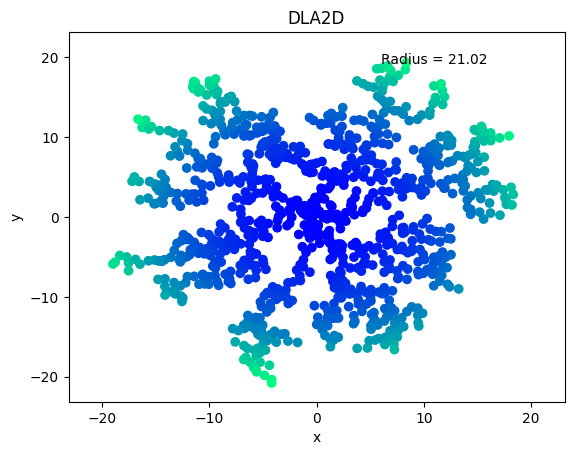

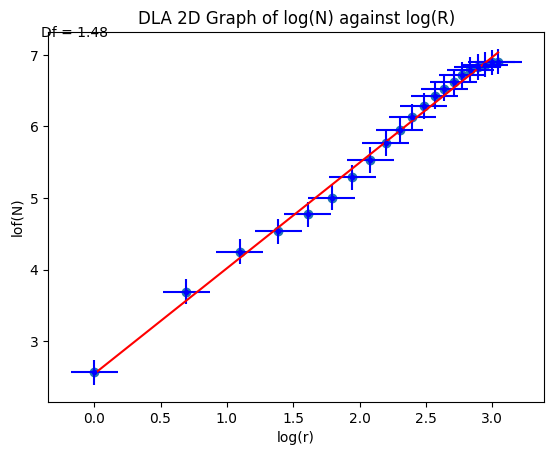

In [3]:
if __name__ == "__main__":
    # Generates a plot of a 2D lattice.
    Walk2D(1000, 1234)